# Representation and head change along the lineage (axis-200-900)

How far does real-data fine-tuning move the pretrained representation, does it move it towards the baseline representation, how much does the head change, and how much decodable information does the head use at each stage?

## Introduction

The thesis tested in parts 2-6 is that synthetic pretraining improves on the model trained on real data only.
Every table therefore contains the **real-only baseline** of the same axis (10 real epochs from the same
initialization) and every comparison is a **paired difference to that baseline**.

The ten pretraining variants differ only in the synthetic data seen before real data (campaign methodology,
`pretraining_campaign_methodology.md`):

| Variant | Synthetic phases | Construction |
| --- | --- | --- |
| P0 single bins | 1 x 10 epochs | ten spectra per axis bin; annotated bins carry their labels, blank bins are known negatives |
| P1 permutations | 1 x 10 epochs | component-token bag (30 per class and per blank bin) packed into mixed spectra |
| P2 joint / staged | 1 x 10 / 2 x 10 epochs | P0 and P1 rows shuffled together / P0 first, then P1 |
| P3 joint / staged | as P2 | P2 + overlap quota (30 extra tokens per class that shares a bin with another class in a training pixel) |
| P4 joint / staged | as P2 | P2 + rare quota (30 extra tokens per class of the least-annotated quarter) |
| P5 joint / staged | as P2 | P2 + both quotas |

Every variant yields three models along one lineage (stages): `pretrained`, `frozen_head` and `unfrozen_head`.
The staged schedules train twice as many synthetic epochs as the joint ones, so schedule and budget are
confounded (methodology, "Pretraining ablation").

### Assumptions

* **Pairing.** Repetition $r$ uses one initialization seed for the baseline and for every variant and stage
  (verified for all 310 models in the campaign-plan verification). The difference between a variant and the
  baseline of the same repetition removes the initialization effect; the five repetitions are the independent
  units. Pixels are not independent units and never enter a test as such.
* **Data.** Every model is evaluated on identical pixels: the same `train`, `test`, `test_extended` and
  `heldout_image` populations as in part 1, decoded once in the shared cache.
* **Objectives.** Synthetic phases: Masserstein (1.0) + BCE (0.2) on complete synthetic targets. Real phases
  (baseline and both fine-tuning stages): Masserstein (1.0) + VPU (0.2) + contractive (2e-3) + InfoNCE (1e-3,
  multilabel-Jaccard negatives, added by mistake and kept because every model used it).
* **Threshold metrics.** Precision, recall and F1 use $\hat Y \ge 0.5$, as in part 1. A head whose
  probabilities never reach 0.5 on real data has F1 = 0 although its ranking may still carry information;
  average precision is threshold free and is the primary head metric.
* **Uncertainty.** With five repetitions the Student-t interval has 4 degrees of freedom
  ($t_{0.975,4} = 2.78$); an interval that excludes zero is a strong statement, one that includes zero is not
  evidence of no effect.

For latent-geometry quantities (effective rank, participation ratio, TwoNN dimension, neighbourhood label
agreement, ...) there is no better direction; their "improvement" is the plain difference $v_r - b_r$.

### Notation

* $b_r$, $v_r$: value of a metric for the baseline and for a variant (at one stage) in repetition $r$.
* $s_m \in \{-1, +1\}$: direction of metric $m$; $-1$ for lower-is-better metrics (Masserstein $W_1$,
  spectral angle, MSE, Hamming loss, window contribution and within-window $W_1$, absolute mass imbalance, ECE,
  Brier score, true-label rank, false-positive rate and lift, losses), $+1$ otherwise.
* **Improvement** $\Delta_r = s_m (v_r - b_r)$: positive is always better than the baseline.
  **Relative improvement** $\Delta_r / |b_r|$.
* Summary over repetitions: mean $\bar\Delta$, SD $s$, interval $\bar\Delta \pm t_{0.975, n-1}\, s / \sqrt{n}$,
  and the numbers of repetitions with $\Delta_r > 0$ (`+k`) and $\Delta_r < 0$ (`-m`).
* Evaluations: `test` (withheld pixels of training images), `test_combined` (test + rare-class extension, the
  main per-class estimate), `heldout_image` (three images never seen; pooled), `heldout_image_per_image` (mean of
  the per-image values; pooled held-out values understate the ranking because annotations are incomplete across
  images, part 1_08).
* $W_1$: exact one-dimensional Wasserstein-1 distance between TIC-normalized input and reconstruction (m/z
  units); $u$: canonical latent code (LayerNorm affine removed).

* Angle between the canonical codes of one pixel in two models: $\theta = 2\,\mathrm{atan2}(\lVert\hat a -
  \hat b\rVert, \lVert\hat a + \hat b\rVert)$ (numerically stable form of $\arccos(\hat a^{\top}\hat b)$).
* Relative head change of a tensor: $\lVert T - T_{\mathrm{pre}}\rVert_F / \lVert T_{\mathrm{pre}}\rVert_F$.

## Configuration

In [1]:
import logging
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Library modules log INFO to stdout; warnings stay visible, progress messages do not.
logging.disable(logging.INFO)
current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import pretraining_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_precompute import (
    load_metadata, load_table, run_command,
)
from msi_autoencoder_wrapper.analysis.precompute.notebook_inputs import load_model_catalog, load_visualization_theme
from msi_autoencoder_wrapper.visualization import pretraining as figures

SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml")
ANALYSIS = "stage_representation_change"
AXIS = "axis-200-900"
STAGE = None

settings = campaign.load_settings(SETTINGS_PATH)
theme = load_visualization_theme(settings).with_overrides(figure_dpi=100)
catalog = load_model_catalog(settings)
metadata = load_metadata(settings, ANALYSIS, AXIS, STAGE)
pd.set_option("display.precision", 4)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)


def table(name: str) -> pd.DataFrame:
    """Load one canonical table written for this notebook by the precompute."""
    return load_table(settings, ANALYSIS, name, AXIS, STAGE)


def mean_sd(frame: pd.DataFrame, keys: list, columns: list) -> pd.DataFrame:
    """Mean and SD over repetitions of the given columns (presentation helper)."""
    long = frame.melt(id_vars=keys, value_vars=columns, var_name="quantity", value_name="value")
    return long.groupby([*keys, "quantity"]).value.agg(["mean", "std"]).unstack("quantity")


POPULATION_COLORS = {name: figures.population_color(name, theme) for name in figures.POPULATION_ORDER}
print("Analysis:", ANALYSIS, "| axis:", AXIS, "| stage:", STAGE, "| models:", metadata["models"] if isinstance(metadata["models"], int) else len(metadata["models"]))
print("Cache keys:", metadata["cache_keys"])

BASELINE = "baseline"
VARIANTS = list(settings["variants"])
VARIANT_LABELS = {BASELINE: "real-only baseline", **{name: value["label"] for name, value in settings["variants"].items()}}
## The baseline keeps its catalog colour (the dark theme baseline colour is reserved for reference lines)
BASELINE_COLOR = next(value["visualization"]["color"] for value in settings["models"].values()
                      if value.get("select", {}).get("role") == settings["baseline_role"])
VARIANT_COLORS = {BASELINE: BASELINE_COLOR, **{name: value["color"] for name, value in settings["variants"].items()}}
STAGES = list(settings["stages"])
STAGE_LABELS = {"real_only": "real-only baseline", **{name: value["label"] for name, value in settings["stages"].items()}}
KEY_METRICS = settings["comparison"]["key_metrics"]
AXES = list(settings["axes"])
AXIS_LABELS = {name: value["label"] for name, value in settings["axes"].items()}
SHORT = {"masserstein": "W1", "spectral_angle": "spectral angle", "average_precision": "macro AP",
         "micro_average_precision": "micro AP", "f1": "macro F1 at 0.5"}
EVALUATION_NAMES = {**figures.DISPLAY_NAMES, "heldout_image_per_image": "held-out, per image"}


def key_panels(reconstruction=("test", "heldout_image"), prediction=("test_combined", "heldout_image_per_image")):
    """Forest-plot panels of the key metrics: (title, row selector)."""
    panels = []
    for spec in KEY_METRICS:
        for evaluation in (reconstruction if spec["family"] == "reconstruction" else prediction):
            selector = {"family": spec["family"], "metric": spec["metric"], "evaluation": evaluation,
                        "ranking": spec.get("ranking", "none")}
            panels.append((f"{SHORT.get(spec['metric'], spec['metric'])}, {EVALUATION_NAMES.get(evaluation, evaluation)}", selector))
    return panels


def interval(frame, digits=3):
    """'mean [ci_low, ci_high] (+k/-m)' strings of a summary table."""
    form = "{:." + str(digits) + "g}"
    return (frame["mean"].map(form.format) + " [" + frame.ci_low.map(form.format) + ", "
            + frame.ci_high.map(form.format) + "] (+" + frame.positive.astype(int).astype(str) + "/-"
            + frame.negative.astype(int).astype(str) + ")")

from msi_autoencoder_wrapper.analysis.autoencoder.experiments.pretraining_campaign_comparison import summarize

ORDER = [BASELINE, *VARIANTS]

drift = table('drift')
similarity = table('similarity')
drift['pair'] = drift.source + ' -> ' + drift.target
similarity['pair'] = similarity.source + ' -> ' + similarity.target
PAIRS = ['pretrained -> frozen_head', 'pretrained -> unfrozen_head', 'frozen_head -> unfrozen_head']

Analysis: stage_representation_change | axis: axis-200-900 | stage: None | models: 155
Cache keys: {'plan': 'f34a92a8f6f7833f', 'populations': '513690bdd78a83ce', 'synthetic_reference': '6ba5bc1e0839ba0e', 'inference': '0243c1efb93b9c4c'}


## Producing the tables this notebook reads

### Methodology

#### Implementation

`stage_representation_change` loads the canonical codes of every stage of a lineage and of the baseline of
the same repetition on identical test and held-out pixels, computes per-pixel angles and the pairwise
battery of part 1_06, compares the head tensors of the saved artifacts with the pretrained head, and fits
the ridge probe for every model of the axis.

The command below is generated by the precompute entry point itself; if a table is missing, `load_table` raises with the same command.

In [2]:
print(run_command(settings, ANALYSIS))

nohup uv run --extra cu118 python -m msi_autoencoder_wrapper.analysis.precompute --settings /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/analysis_settings.yaml --analysis stage_representation_change > /home/max/repositories/MSIAutoEncoderWrapper/assets/experiments/autoencoder_architecture/notebooks/segmentation_model/20_09_metaspace_pretrain/shared_precompute.log 2>&1 &


### Remarks

### Notes

## Per-pixel latent drift between stages

### Methodology

#### Theoretical

The angle between the codes of one pixel before and after a fine-tuning step. Because the frozen and the
unfrozen stage start from the same pretrained model, a similar drift in both means that the head's freedom
barely changes where the representation goes.

#### Implementation

`drift` (per lineage, transition and population: mean and quantiles of the angle).

#### Figure descriptions

One panel per population; x = variant, colour = transition, one point per repetition (mean angle).

q10_angle_degrees       q50_angle_degrees       q90_angle_degrees      
population                                         heldout_image  test     heldout_image  test     heldout_image  test
variant           pair                                                                                                
P0_single         frozen_head -> unfrozen_head              13.3  13.9              15.4  18.7              18.9  26.0
                  pretrained -> frozen_head                 31.3  27.2              39.2  39.0              49.5  53.7
                  pretrained -> unfrozen_head               28.3  29.2              39.5  39.6              48.8  52.0
P1_permutation    frozen_head -> unfrozen_head              10.0   9.7              12.0  12.9              13.4  15.7
                  pretrained -> frozen_head                 17.7  20.0              23.4  33.8              27.5  44.7
                  pretrained -> unfrozen_head               23.2  23.4              28.9  32.4              32.9  41.8
P2_joint_base     frozen_head -> unfrozen_head              11.5  10.5              14.0  14.3              17.0  22.1
                  pretrained -> frozen_head                 27.9  27.0              36.4  34.5              39.6  41.9
                  pretrained -> unfrozen_head               21.8  20.4              29.3  29.1              32.1  38.3
P2_staged_base    frozen_head -> unfrozen_head              13.0  12.5              16.1  15.4              18.9  27.2
                  pretrained -> frozen_head                 24.0  24.6              31.5  33.7              36.3  43.8
                  pretrained -> unfrozen_head               18.7  20.4              24.9  30.2              30.2  41.6
P3_joint_overlap  frozen_head -> unfrozen_head               9.8  11.2              12.9  16.2              18.2  28.4
                  pretrained -> frozen_head                 30.7  27.0              37.7  36.6              43.3  44.7
                  pretrained -> unfrozen_head               29.2  22.9              34.1  31.9              39.0  40.4
P3_staged_overlap frozen_head -> unfrozen_head              12.0  12.1              14.7  15.3              18.8  25.1
                  pretrained -> frozen_head                 27.3  26.4              32.1  36.0              36.4  47.4
                  pretrained -> unfrozen_head               19.0  19.5              23.6  30.0              28.3  43.8
P4_joint_rare     frozen_head -> unfrozen_head              10.7  10.3              12.5  15.1              19.0  24.2
                  pretrained -> frozen_head                 30.3  25.3              35.9  34.4              39.1  42.8
                  pretrained -> unfrozen_head               22.4  22.6              30.7  30.2              34.1  37.1
P4_staged_rare    frozen_head -> unfrozen_head              13.0  11.7              14.7  15.5              18.9  25.2
                  pretrained -> frozen_head                 25.9  26.5              33.2  35.9              37.0  45.8
                  pretrained -> unfrozen_head               20.9  21.8              26.8  31.4              32.7  42.4
P5_joint_all      frozen_head -> unfrozen_head              11.4  11.6              13.7  16.3              21.2  24.8
                  pretrained -> frozen_head                 26.6  23.9              32.6  31.6              36.0  39.4
                  pretrained -> unfrozen_head               20.3  20.1              26.7  27.6              30.4  36.8
P5_staged_all     frozen_head -> unfrozen_head              12.8  12.5              14.9  15.1              17.1  26.2
                  pretrained -> frozen_head                 26.5  27.9              35.3  37.6              39.7  47.1
                  pretrained -> unfrozen_head               22.3  22.5              27.9  31.9              33.6  41.7

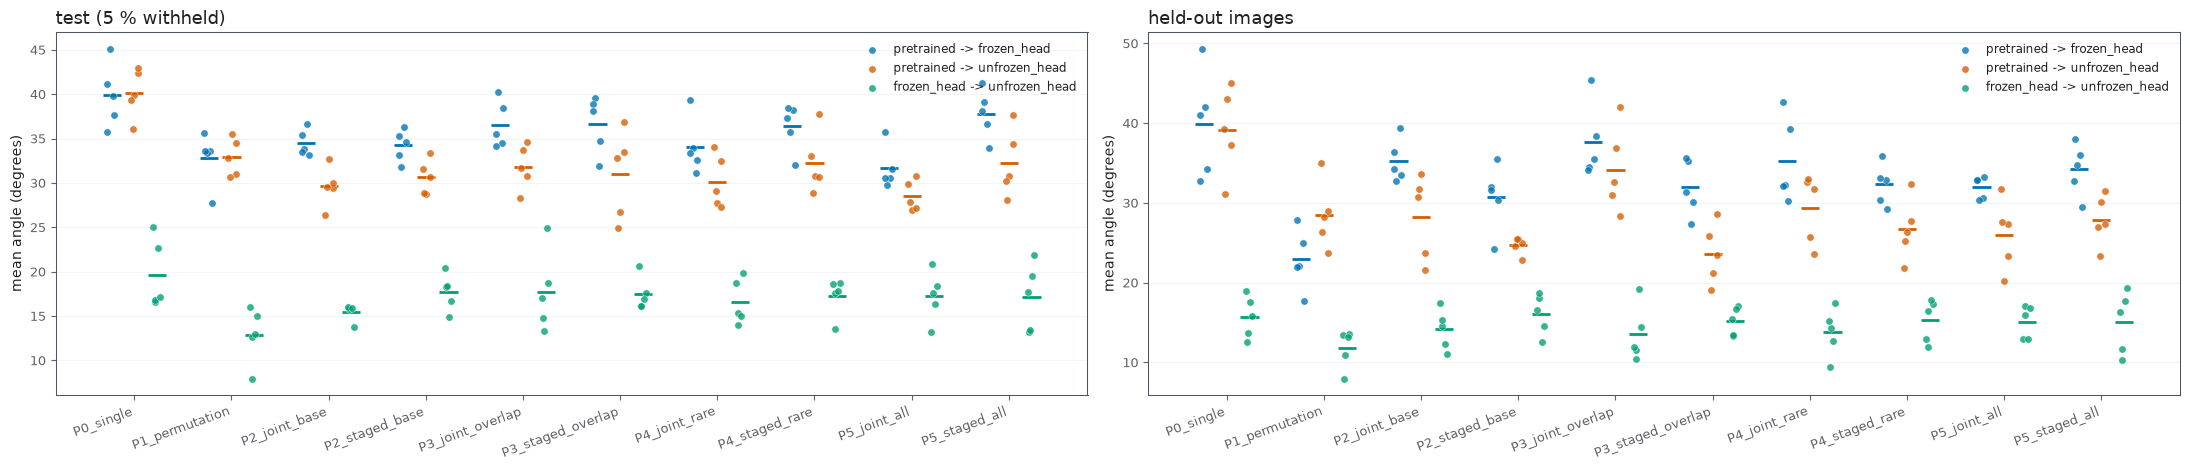

In [3]:
figure, axes = plt.subplots(1, 2, figsize=(22, 4.8), dpi=theme.figure_dpi)
for ax, population in zip(axes, ['test', 'heldout_image']):
    figures.repetition_points(drift[drift.population == population], value='mean_angle_degrees', group='variant', hue='pair', order=VARIANTS,
                              hue_order=PAIRS, colors=dict(zip(PAIRS, theme.model_palette)), ylabel='mean angle (degrees)',
                              title=EVALUATION_NAMES[population], ax=ax, theme=theme)
figure.tight_layout()
display(drift.groupby(['variant', 'pair', 'population'])[['q10_angle_degrees', 'q50_angle_degrees', 'q90_angle_degrees']].mean()
        .unstack('population').round(1))

### Remarks

- Median per-pixel angle (test, mean over variants and repetitions): frozen_head -> unfrozen_head 15.5 degrees; pretrained -> frozen_head 35.3 degrees; pretrained -> unfrozen_head 31.4 degrees.

### Notes

## Similarity between stages and to the baseline

### Methodology

#### Theoretical

Linear CKA and $k$-NN overlap between the stages of a lineage and between every stage and the baseline of
the same repetition. If fine-tuning pulls the representation towards the baseline, the similarity to the
baseline rises from the pretrained to the fine-tuned stages.

#### Implementation

`similarity` (pairwise battery on the latent sample).

#### Figure descriptions

One panel per quantity (test pixels); x = variant, colour = pair; the table gives repetition means on both populations.

linear_cka          knn_overlap        procrustes_distance       
population                   heldout_image   test heldout_image   test       heldout_image   test
pair                                                                                             
pretrained -> frozen_head            0.974  0.771         0.377  0.454               0.258  0.558
pretrained -> unfrozen_head          0.975  0.793         0.380  0.457               0.252  0.543
frozen_head -> unfrozen_head         0.999  0.984         0.831  0.850               0.065  0.146
pretrained -> baseline               0.974  0.780         0.369  0.448               0.261  0.566
frozen_head -> baseline              0.997  0.957         0.714  0.755               0.119  0.280
unfrozen_head -> baseline            0.998  0.971         0.729  0.768               0.107  0.253

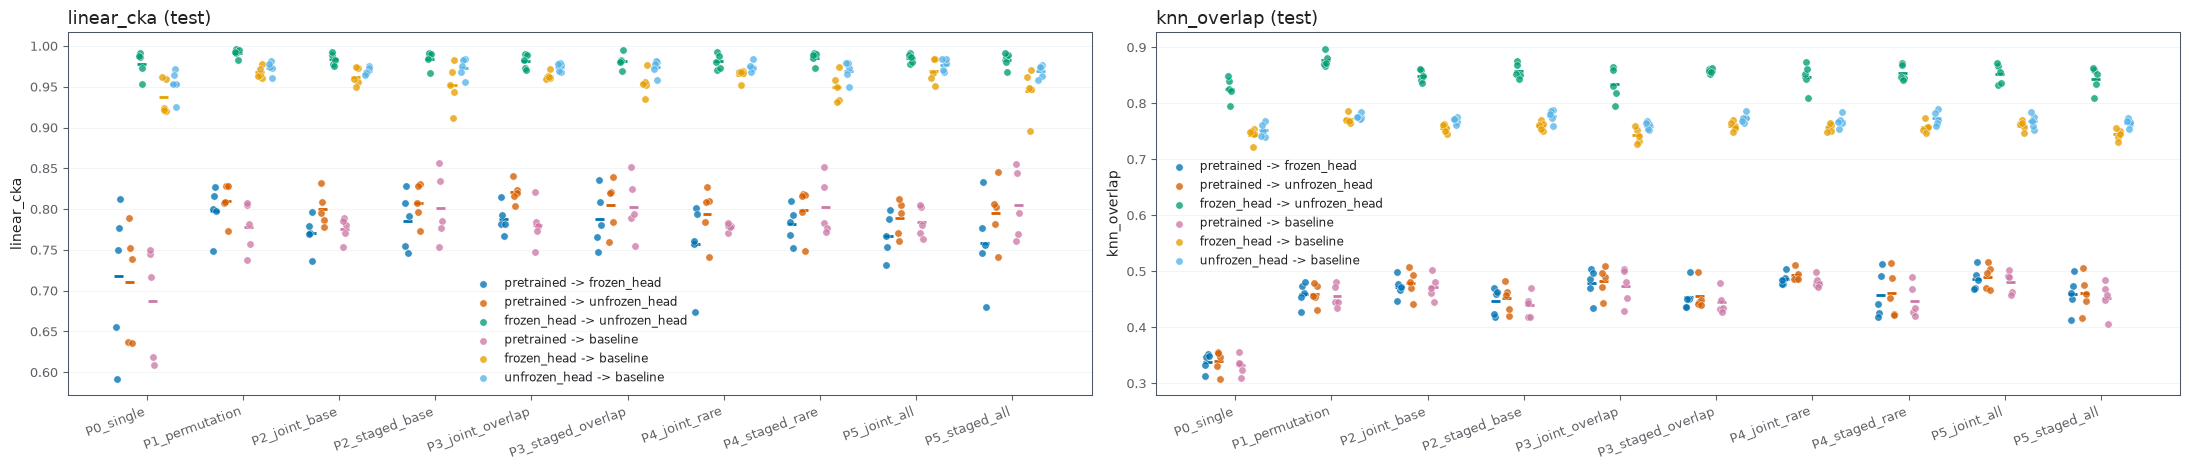

In [4]:
ALL_PAIRS = [*PAIRS, 'pretrained -> baseline', 'frozen_head -> baseline', 'unfrozen_head -> baseline']
figure, axes = plt.subplots(1, 2, figsize=(22, 4.8), dpi=theme.figure_dpi)
for ax, quantity in zip(axes, ['linear_cka', 'knn_overlap']):
    figures.repetition_points(similarity[similarity.population == 'test'], value=quantity, group='variant', hue='pair', order=VARIANTS,
                              hue_order=ALL_PAIRS, colors=dict(zip(ALL_PAIRS, theme.model_palette)), ylabel=quantity, title=f'{quantity} (test)', ax=ax, theme=theme)
figure.tight_layout()
display(similarity.groupby(['pair', 'population'])[['linear_cka', 'knn_overlap', 'procrustes_distance']].mean().unstack('population').reindex(ALL_PAIRS).round(3))

### Remarks

- Linear CKA (held-out / test): pretrained -> baseline 0.974 / 0.78; frozen_head -> baseline 0.997 / 0.957; unfrozen_head -> baseline 0.998 / 0.971; frozen_head -> unfrozen_head 0.999 / 0.984.

### Notes

## Change of the head tensors

### Methodology

#### Theoretical

Relative Frobenius change of every head tensor against the pretrained head. The frozen stage must show
exactly zero (the head was frozen); the unfrozen stage shows how much 10 real epochs rewrite the synthetic
head.

#### Implementation

`head_change` (per lineage, stage and tensor), read from the saved artifacts.

#### Figure descriptions

No figure; mean and maximum relative change per stage, variant and tensor.

In [5]:
head = table('head_change')
display(head.groupby(['stage', 'tensor']).relative_change.agg(['mean', 'min', 'max']).round(4))
display(head[head.stage == 'unfrozen_head'].groupby(['variant', 'tensor']).relative_change.mean().unstack().reindex(VARIANTS).round(3))

mean     min     max
stage         tensor                                                     
frozen_head   heads.molecule_vpu.network.0.bias    0.0000  0.0000  0.0000
              heads.molecule_vpu.network.0.weight  0.0000  0.0000  0.0000
              heads.molecule_vpu.network.3.bias    0.0000  0.0000  0.0000
              heads.molecule_vpu.network.3.weight  0.0000  0.0000  0.0000
unfrozen_head heads.molecule_vpu.network.0.bias    0.6415  0.4426  0.8634
              heads.molecule_vpu.network.0.weight  1.0149  0.7030  1.9521
              heads.molecule_vpu.network.3.bias    5.3547  3.7565  7.0022
              heads.molecule_vpu.network.3.weight  2.7579  1.7871  5.6513

tensor,heads.molecule_vpu.network.0.bias,heads.molecule_vpu.network.0.weight,heads.molecule_vpu.network.3.bias,heads.molecule_vpu.network.3.weight
variant,,,,
P0_single,0.717,0.872,5.876,2.195
P1_permutation,0.702,1.846,6.470,5.152
P2_joint_base,0.497,0.885,5.814,2.455
P2_staged_base,0.733,0.993,4.298,2.601
P3_joint_overlap,0.585,0.956,6.052,2.730
P3_staged_overlap,0.712,0.958,4.314,2.428
P4_joint_rare,0.562,0.894,6.165,2.514
P4_staged_rare,0.713,0.940,4.202,2.478
P5_joint_all,0.533,0.892,6.234,2.615


### Remarks

- Frozen head: relative change 0 for every tensor (exactly frozen). Unfrozen head: 0.44-7; the output bias changes most (the synthetic head's offset is rewritten).

### Notes

## Probe against head at every stage

### Methodology

#### Theoretical

Probe minus head macro AP (see the latent notebooks) for every model of the axis, now across stages. A large
positive value at the pretrained and frozen stage and a value near the baseline's at the unfrozen stage
would mean that the representation carries the annotation information but only a retrained head reads it.

#### Implementation

`probe_versus_head` (per model; roles `real_only`, `pretrained`, `frozen_head`, `unfrozen_head`).

#### Figure descriptions

One panel per evaluation; x = variant (baseline first), colour = stage, one point per repetition.

value_probe                  value_head               probe_minus_head              
evaluation    heldout_image test_combined heldout_image test_combined    heldout_image test_combined
role                                                                                                
real_only             0.319         0.544         0.356         0.709           -0.037        -0.165
pretrained            0.319         0.455         0.261         0.094            0.058         0.361
frozen_head           0.320         0.542         0.246         0.239            0.075         0.303
unfrozen_head         0.316         0.527         0.347         0.709           -0.031        -0.182

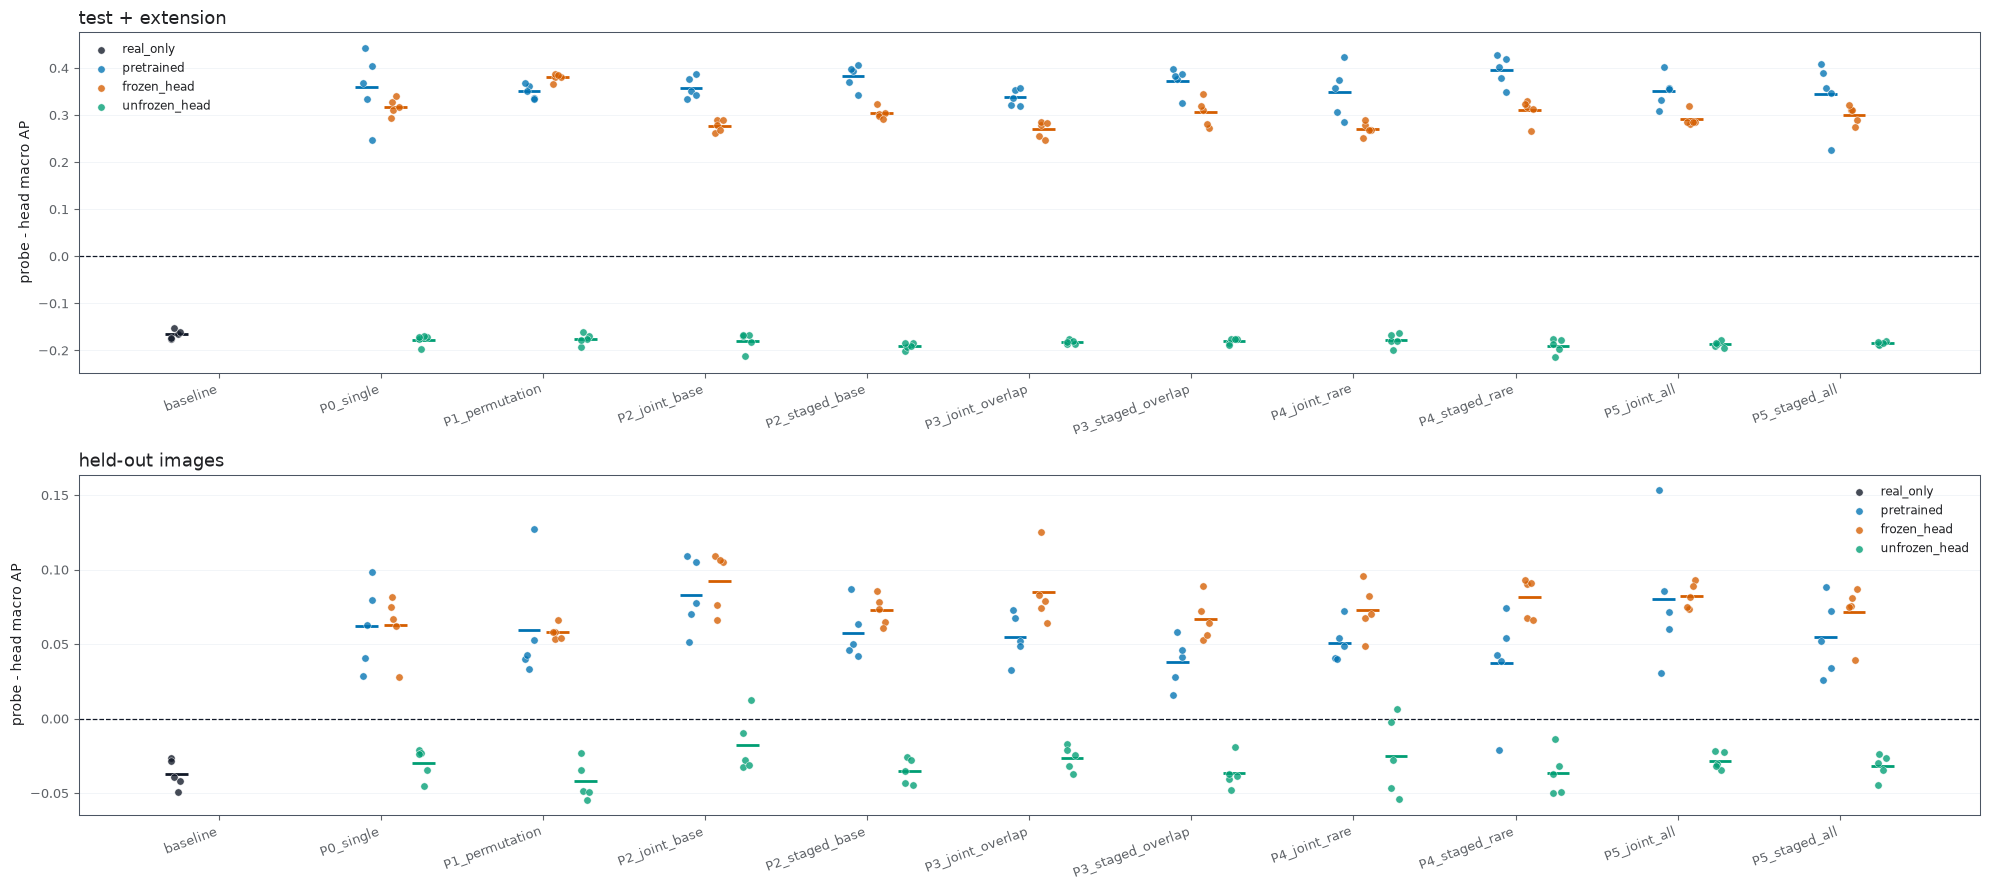

In [6]:
versus = table('probe_versus_head')
versus = versus[versus.metric == 'average_precision']
ROLES = ['real_only', *STAGES]
figure, axes = plt.subplots(2, 1, figsize=(20, 9), dpi=theme.figure_dpi)
for ax, evaluation in zip(axes, ['test_combined', 'heldout_image']):
    figures.repetition_points(versus[versus.evaluation == evaluation], value='probe_minus_head', group='variant', hue='role', order=ORDER, hue_order=ROLES,
                              colors=dict(zip(ROLES, [theme.baseline_color, *theme.model_palette])), ylabel='probe - head macro AP',
                              title=EVALUATION_NAMES[evaluation], reference=0.0, ax=ax, theme=theme)
figure.tight_layout()
display(versus.groupby(['role', 'evaluation'])[['value_probe', 'value_head', 'probe_minus_head']].mean().unstack('evaluation').reindex(ROLES).round(3))

### Remarks

- Probe / head macro AP (test + extension): baseline 0.544 / 0.709; pretrained 0.455 / 0.0943; frozen head 0.542 / 0.239; unfrozen head 0.527 / 0.709.

### Notes

## Results / Summary

### LLM

- **Observed:** fine-tuning rotates the canonical codes by a median of about 31-35 degrees per pixel; the frozen and unfrozen stages of one lineage end about 15 degrees apart. The linear CKA to the baseline rises from 0.78 (pretrained, test) to 0.96-0.97 after fine-tuning (0.997-0.998 on held-out pixels).
- **Observed:** probe AP is about equal at every stage (0.46-0.54), while head AP goes 0.09 -> 0.24 -> 0.71.
- **Interpretation:** real fine-tuning moves every pretrained representation much closer to the baseline's (CKA 0.78 -> 0.96-0.97 on test pixels; how close two baseline repetitions are to each other was not measured, so 'the same solution' cannot be claimed); the annotation information is linearly present in the representation from the start, and the head is what has to be learned from real data.

### Person